### Day 1

In [3]:
from multiprocessing.reduction import duplicate
from pathlib import Path
from unittest import result

from IPython.core.pylabtools import figsize
from PIL import Image
from contourpy import as_z_interp

DATA_DIR = Path("../data/raw")

valid_images = []
invalid_images = []

for class_dir in DATA_DIR.iterdir():
    if not class_dir.is_dir():
        continue

    for image_path in class_dir.glob("*.jpg"):
        try:
            with Image.open(image_path) as img:
                img.verify()

            valid_images.append(image_path)

        except Exception as e:
            invalid_images.append((image_path, str(e)))

print(f"Valid images: {len(valid_images)}")
print(f"Invalid images: {len(invalid_images)}")

if invalid_images:
    print("\nInvalid files:")
    for path, error in invalid_images:
        print(path, "->", error)

Valid images: 119
Invalid images: 0


In [4]:
image_properties = []

for class_dir in DATA_DIR.iterdir():
    if not class_dir.is_dir():
        continue

    for image_path in class_dir.glob("*.jpg"):
        with Image.open(image_path) as img:
            image_properties.append({
                "class": class_dir.name,
                "filename": image_path.name,
                "width": img.width,
                "height": img.height,
                "mode": img.mode
            })

print(f"Images inspected: {len(image_properties)}")

Images inspected: 119


In [5]:
from collections import Counter

dimensions = Counter(
    (item["width"], item["height"])
    for item in image_properties
)

modes = Counter(
    item["mode"]
    for item in image_properties
)

print("Unique image dimensions:")
for dimension, count in dimensions.items():
    print(f"{dimensions}: {count}")

print("\nColor modes:")
for mode, count in modes.items():
    print(f"{mode} : {count}")

Unique image dimensions:
Counter({(3081, 897): 85, (250, 200): 2, (766, 250): 1, (617, 244): 1, (1530, 371): 1, (1480, 279): 1, (1504, 323): 1, (765, 224): 1, (763, 268): 1, (699, 197): 1, (456, 124): 1, (316, 127): 1, (427, 193): 1, (768, 514): 1, (296, 88): 1, (286, 92): 1, (340, 94): 1, (467, 104): 1, (359, 168): 1, (311, 170): 1, (1200, 900): 1, (376, 80): 1, (367, 73): 1, (301, 71): 1, (614, 409): 1, (946, 255): 1, (948, 233): 1, (948, 211): 1, (537, 216): 1, (503, 174): 1, (510, 383): 1, (565, 233): 1, (562, 217): 1, (741, 291): 1}): 85
Counter({(3081, 897): 85, (250, 200): 2, (766, 250): 1, (617, 244): 1, (1530, 371): 1, (1480, 279): 1, (1504, 323): 1, (765, 224): 1, (763, 268): 1, (699, 197): 1, (456, 124): 1, (316, 127): 1, (427, 193): 1, (768, 514): 1, (296, 88): 1, (286, 92): 1, (340, 94): 1, (467, 104): 1, (359, 168): 1, (311, 170): 1, (1200, 900): 1, (376, 80): 1, (367, 73): 1, (301, 71): 1, (614, 409): 1, (946, 255): 1, (948, 233): 1, (948, 211): 1, (537, 216): 1, (503, 1

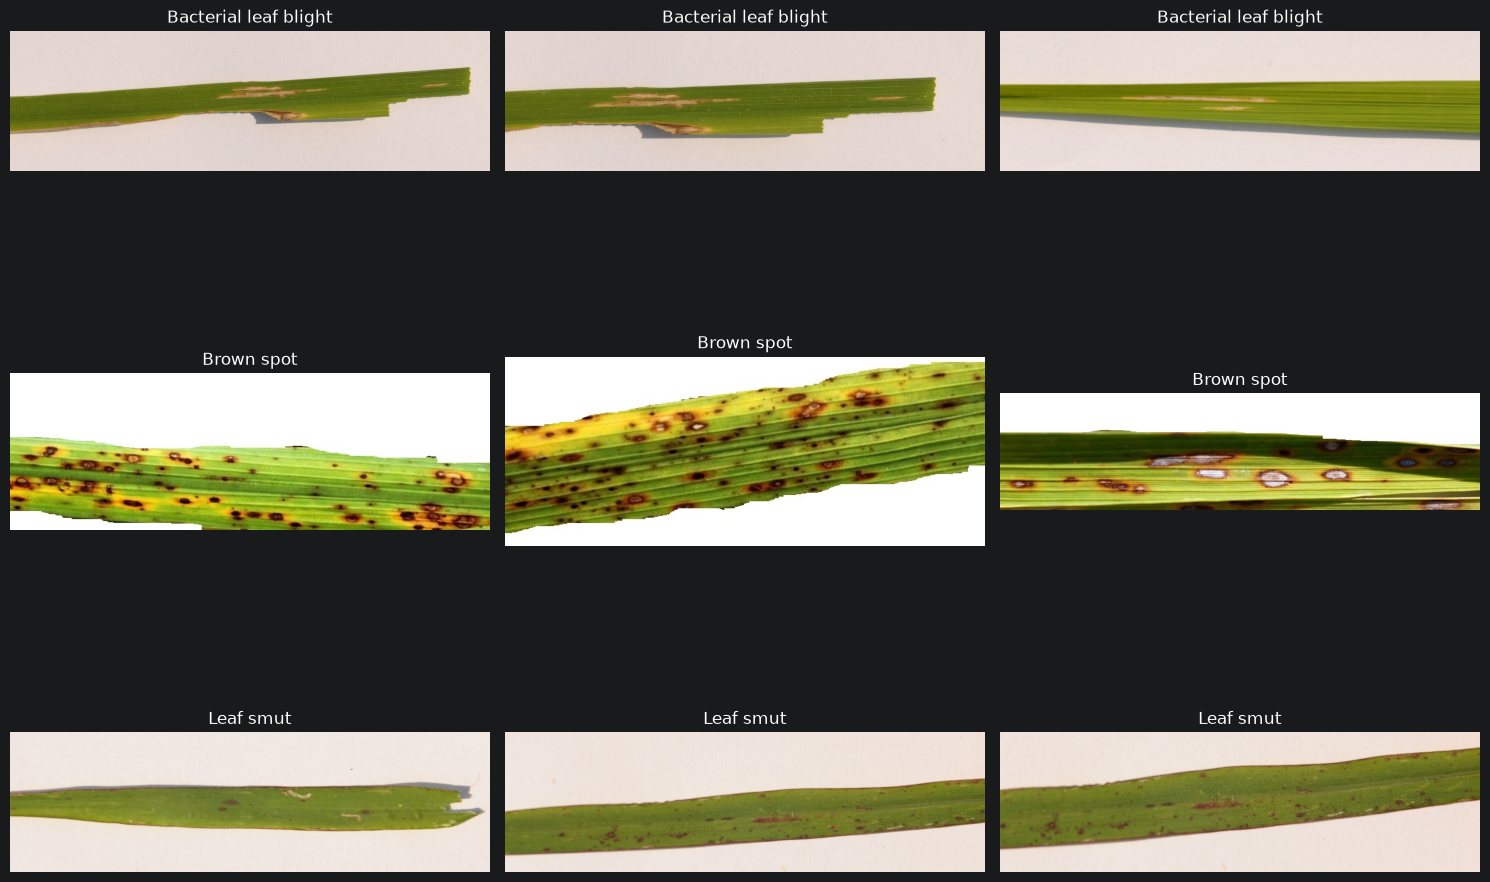

In [6]:
import matplotlib.pyplot as plt
classes = [d for d in DATA_DIR.iterdir() if d.is_dir()]

fig, axes = plt.subplots(3,3, figsize=(15,12))

for row, class_dir in enumerate(classes):
    image_paths = list(class_dir.glob("*.jpg"))[:3]

    for col, image_path in enumerate(image_paths):
        with Image.open(image_path) as img:
            axes[row, col].imshow(img)
            axes[row, col].set_title(class_dir.name)
            axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [7]:
from collections import Counter

for class_dir in classes:
    class_dimensions = Counter()

    for image_path in class_dir.glob("*.jpg"):
        with Image.open(image_path) as img:
            class_dimensions[(img.width, img.height)] += 1

    print(f"\n{class_dir.name}")
    for dimension, count in class_dimensions.most_common():
        print(f" {dimension}: {count}")


Bacterial leaf blight
 (3081, 897): 40

Brown spot
 (3081, 897): 21
 (766, 250): 1
 (617, 244): 1
 (1530, 371): 1
 (1480, 279): 1
 (1504, 323): 1
 (765, 224): 1
 (763, 268): 1
 (699, 197): 1
 (456, 124): 1
 (316, 127): 1
 (427, 193): 1
 (768, 514): 1
 (296, 88): 1
 (286, 92): 1
 (340, 94): 1
 (467, 104): 1
 (359, 168): 1
 (311, 170): 1
 (1200, 900): 1

Leaf smut
 (3081, 897): 24
 (250, 200): 2
 (376, 80): 1
 (367, 73): 1
 (301, 71): 1
 (614, 409): 1
 (946, 255): 1
 (948, 233): 1
 (948, 211): 1
 (537, 216): 1
 (503, 174): 1
 (510, 383): 1
 (565, 233): 1
 (562, 217): 1
 (741, 291): 1


In [8]:
import matplotlib.pyplot as plt

wide_image = None
normal_image = None

for class_dir in classes:
    for image_path in class_dir.glob("*.jpg"):
        with Image.open(image_path) as img:
            if img.size == (3081, 897) and wide_image is None:
                wide_image = image_path

            if img.size == (1200, 900) and normal_image is None:
                normal_image = image_path

        if wide_image is not None and normal_image is not None:
            break
    if wide_image is not None and normal_image is not None:
        break

print("Wide image:", wide_image)
print("Normal image:", normal_image)


Wide image: ..\data\raw\Bacterial leaf blight\DSC_0365.JPG
Normal image: ..\data\raw\Brown spot\DSC_0121.jpg


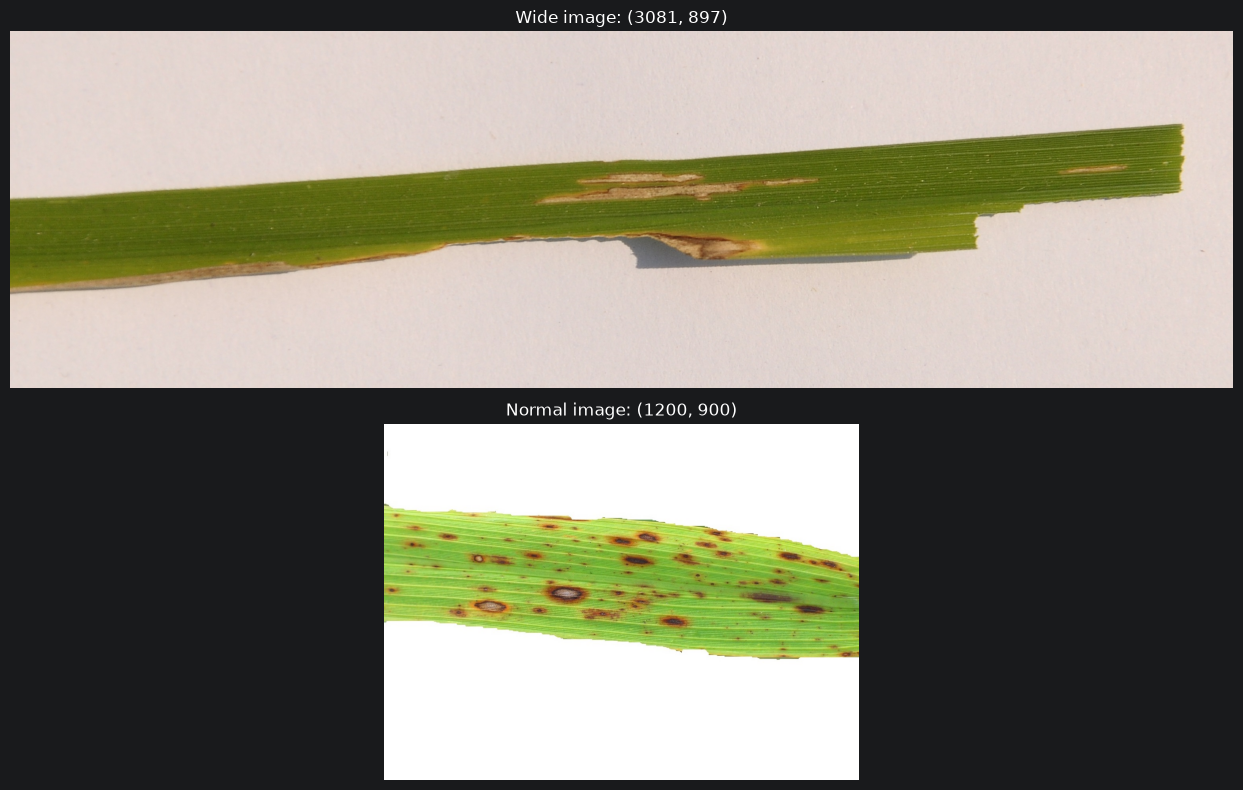

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

with Image.open(wide_image) as img:
    axes[0].imshow(img)
    axes[0].set_title(f"Wide image: {img.size}")
    axes[0].axis("off")

if normal_image is not None:
    with Image.open(normal_image) as img:
        axes[1].imshow(img)
        axes[1].set_title(f"Normal image: {img.size}")
        axes[1].axis("off")

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

df = pd.DataFrame(image_properties)

df["aspect_ratio"] = df["width"] / df["height"]

df.groupby("class")["aspect_ratio"].agg(
    ["count", "min", "max", "mean", "median"]
).round(2)

,count,min,max,mean,median
class,,,,,
Bacterial leaf blight,40,3.43,3.43,3.43,3.43
Brown spot,40,1.33,5.30,3.28,3.43
Leaf smut,39,1.25,5.03,3.25,3.43


In [11]:
df[["class", "width", "height", "aspect_ratio"]].sort_values(
    "aspect_ratio", ascending=False
).head(15)

,class,width,height,aspect_ratio
43,Brown spot,1480,279,5.304659
104,Leaf smut,367,73,5.027397
103,Leaf smut,376,80,4.700000
44,Brown spot,1504,323,4.656347
110,Leaf smut,948,211,4.492891
55,Brown spot,467,104,4.490385
105,Leaf smut,301,71,4.239437
42,Brown spot,1530,371,4.123989
109,Leaf smut,948,233,4.068670
108,Leaf smut,946,255,3.709804


In [12]:
import hashlib
from collections import defaultdict

file_hashes = defaultdict(list)

for class_dir in classes:
    for image_path in class_dir.glob("*.jpg"):
        with open(image_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        file_hashes[file_hash].append(image_path)

duplicates = {
    file_hash: paths
    for file_hash, paths in file_hashes.items()
    if len(paths) > 1
}

print(f"Total files: {len(valid_images)}")
print((f"Unique file contents: {len(file_hashes)}"))
print(f"Duplicate groups: {len(duplicates)}")

for paths in duplicates.values():
    print("\nDuplicate:")
    for path in paths:
        print(" ", path)

Total files: 119
Unique file contents: 119
Duplicate groups: 0


In [13]:
import numpy as np
from PIL import ImageOps

def image_signature(image_path, size=(32, 32)):
    with Image.open(image_path) as img:
        img = img.convert("RGB")

        # Preserve aspect ratio while fitting into a fixed canvas
        img = ImageOps.contain(img, size)

        canvas = Image.new("RGB", size, "white")

        x = (size[0] - img.width) // 2
        y = (size[1] - img.height) // 2

        canvas.paste(img, (x,y))

        arr = np.asarray(canvas, dtype=np.float32)

        # Normalize brightness so comparison focuses less on exposure
        arr = arr / 255.0

        return arr

In [14]:
image_paths = [
    path
    for class_dir in classes
    for path in class_dir.glob("*.jpg")
]

signatures = {
    path: image_signature(path)
    for path in image_paths
}

In [15]:
similar_pairs = []

for i in range(len(image_paths)):
    for j in range(i + 1, len(image_paths)):
        path1 = image_paths[i]
        path2 = image_paths[j]

        diff = np.mean(np.abs(signatures[path1] - signatures[path2]))

        similar_pairs.append((diff, path1, path2))

similar_pairs.sort(key=lambda x: x[0])

for diff, path1, path2 in similar_pairs[:15]:
    print(f"{diff:.4f} | {path1} | {path2}")

0.0074 | ..\data\raw\Leaf smut\DSC_0504.jpg | ..\data\raw\Leaf smut\DSC_0512.jpg
0.0103 | ..\data\raw\Leaf smut\DSC_0322.jpg | ..\data\raw\Leaf smut\DSC_0335.JPG
0.0109 | ..\data\raw\Bacterial leaf blight\DSC_0367.JPG | ..\data\raw\Bacterial leaf blight\DSC_0382.JPG
0.0111 | ..\data\raw\Leaf smut\DSC_0310.JPG | ..\data\raw\Leaf smut\DSC_0321.JPG
0.0114 | ..\data\raw\Brown spot\DSC_0300.JPG | ..\data\raw\Leaf smut\DSC_0316.JPG
0.0114 | ..\data\raw\Brown spot\DSC_0300.JPG | ..\data\raw\Brown spot\DSC_0307.JPG
0.0117 | ..\data\raw\Bacterial leaf blight\DSC_0390.JPG | ..\data\raw\Bacterial leaf blight\DSC_0396.JPG
0.0118 | ..\data\raw\Brown spot\DSC_0300.JPG | ..\data\raw\Leaf smut\DSC_0322.jpg
0.0118 | ..\data\raw\Leaf smut\DSC_0317.JPG | ..\data\raw\Leaf smut\DSC_0319.jpg
0.0121 | ..\data\raw\Leaf smut\DSC_0310.JPG | ..\data\raw\Leaf smut\DSC_0335.JPG
0.0121 | ..\data\raw\Bacterial leaf blight\DSC_0375.JPG | ..\data\raw\Bacterial leaf blight\DSC_0376.JPG
0.0124 | ..\data\raw\Brown spot\D

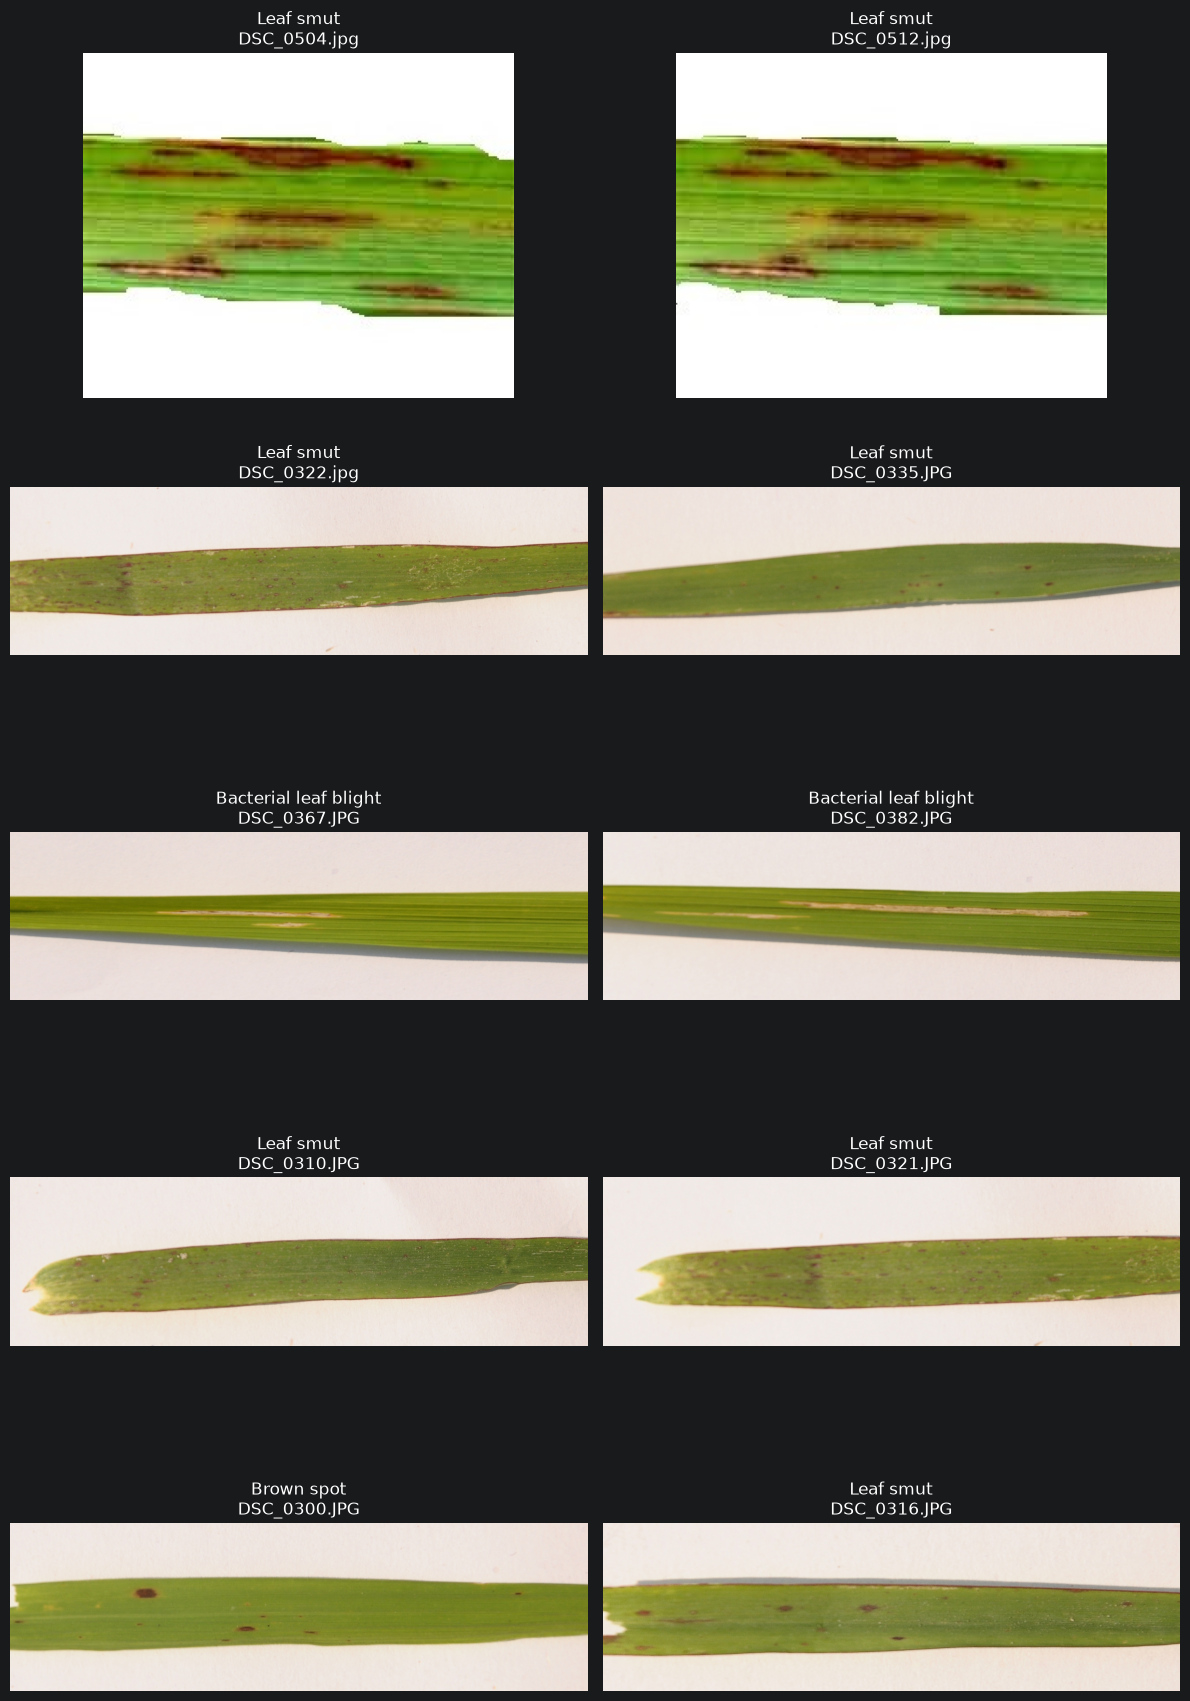

In [16]:
import matplotlib.pyplot as plt

top_pairs = similar_pairs[:5]

fig, axes = plt.subplots(len(top_pairs), 2, figsize=(12, 18))

for row, (diff, path1, path2) in enumerate(top_pairs):

    with Image.open(path1) as img1:
        axes[row, 0].imshow(img1)
        axes[row, 0].set_title(
            f"{path1.parent.name}\n{path1.name}"
        )
        axes[row, 0].axis("off")

    with Image.open(path2) as img2:
        axes[row, 1].imshow(img2)
        axes[row, 1].set_title(
            f"{path2.parent.name}\n{path2.name}"
        )
        axes[row, 1].axis("off")

    axes[row, 0].set_ylabel(f"diff = {diff:.4f}", rotation=90)

plt.tight_layout()
plt.show()

In [17]:
class_counts = df["class"].value_counts()

print(class_counts)

class
Bacterial leaf blight    40
Brown spot               40
Leaf smut                39
Name: count, dtype: int64


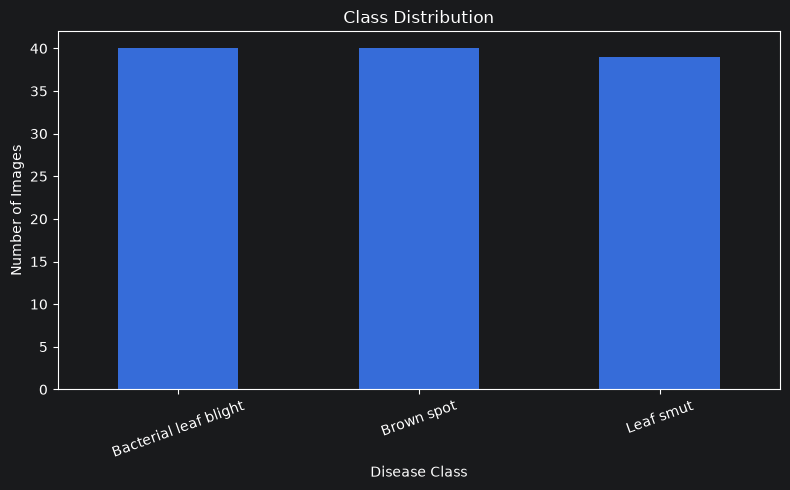

In [18]:
class_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [19]:
import numpy as np

quality_records = []

for class_dir in classes:
    for image_path in class_dir.glob("*.jpg"):
        with Image.open(image_path) as img:
            img_array = np.asarray(img.convert("RGB"), dtype=np.float32)

            mean_brightness = img_array.mean()
            min_pixel = img_array.min()
            max_pixel = img_array.max()

            quality_records.append({
                "class": class_dir.name,
                "filename": image_path.name,
                "mean_brightness": mean_brightness,
                "min_pixel": min_pixel,
                "max_pixel": max_pixel
            })

quality_df =pd.DataFrame(quality_records)

print("Brightness summary:")
print(quality_df["mean_brightness"].describe().round(2))

Brightness summary:
count    119.00
mean     171.83
std       28.08
min       75.94
25%      161.59
50%      179.46
75%      188.10
max      231.25
Name: mean_brightness, dtype: float64


In [20]:
print("\nDarkest images:")
print(
    quality_df.sort_values("mean_brightness")
    [["class", "filename", "mean_brightness"]].head(5)
)

print("\nBrightest images:")
print(
    quality_df.sort_values("mean_brightness", ascending=False)
    [["class", "filename", "mean_brightness"]].head(5)
)


Darkest images:
          class      filename  mean_brightness
116   Leaf smut  DSC_0514.jpg        75.942978
117   Leaf smut  DSC_0515.jpg        87.945557
118   Leaf smut  DSC_0516.jpg        88.707428
112   Leaf smut  DSC_0510.jpg        93.825142
55   Brown spot  DSC_0117.jpg       106.379578

Brightest images:
                     class      filename  mean_brightness
111              Leaf smut  DSC_0509.jpg       231.247406
37   Bacterial leaf blight  DSC_0701.jpg       231.195328
51              Brown spot  DSC_0113.jpg       216.100189
58              Brown spot  DSC_0121.jpg       214.410126
86               Leaf smut  DSC_0314.JPG       214.123184


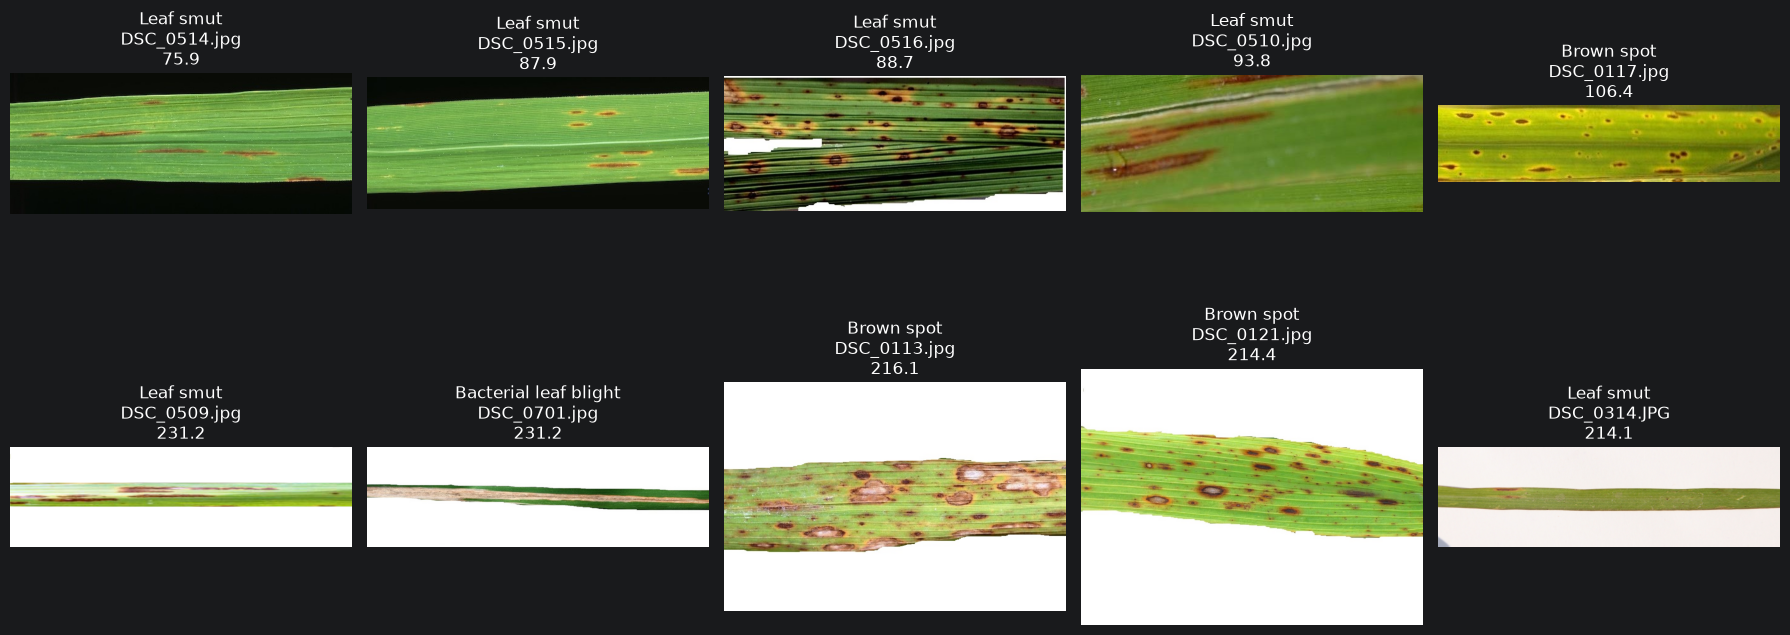

In [21]:
darkest = quality_df.nsmallest(5, "mean_brightness")
brightest = quality_df.nlargest(5, "mean_brightness")

extreme_images = pd.concat([darkest, brightest])

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for col, (_, row) in enumerate(darkest.iterrows()):
    image_path = DATA_DIR / row["class"] / row["filename"]

    with Image.open(image_path) as img:
        axes[0, col].imshow(img)
        axes[0, col].set_title(
            f"{row['class']}\n{row['filename']}\n{row['mean_brightness']:.1f}"
        )
        axes[0, col].axis("off")

for col, (_, row) in enumerate(brightest.iterrows()):
    image_path = DATA_DIR / row["class"] / row["filename"]

    with Image.open(image_path) as img:
        axes[1, col].imshow(img)
        axes[1, col].set_title(
            f"{row['class']}\n{row['filename']}\n{row['mean_brightness']:.1f}"
        )
        axes[1, col].axis("off")

axes[0, 0].set_ylabel("Darkest")
axes[1, 0].set_ylabel("Brightest")

plt.tight_layout()
plt.show()

### Day 2

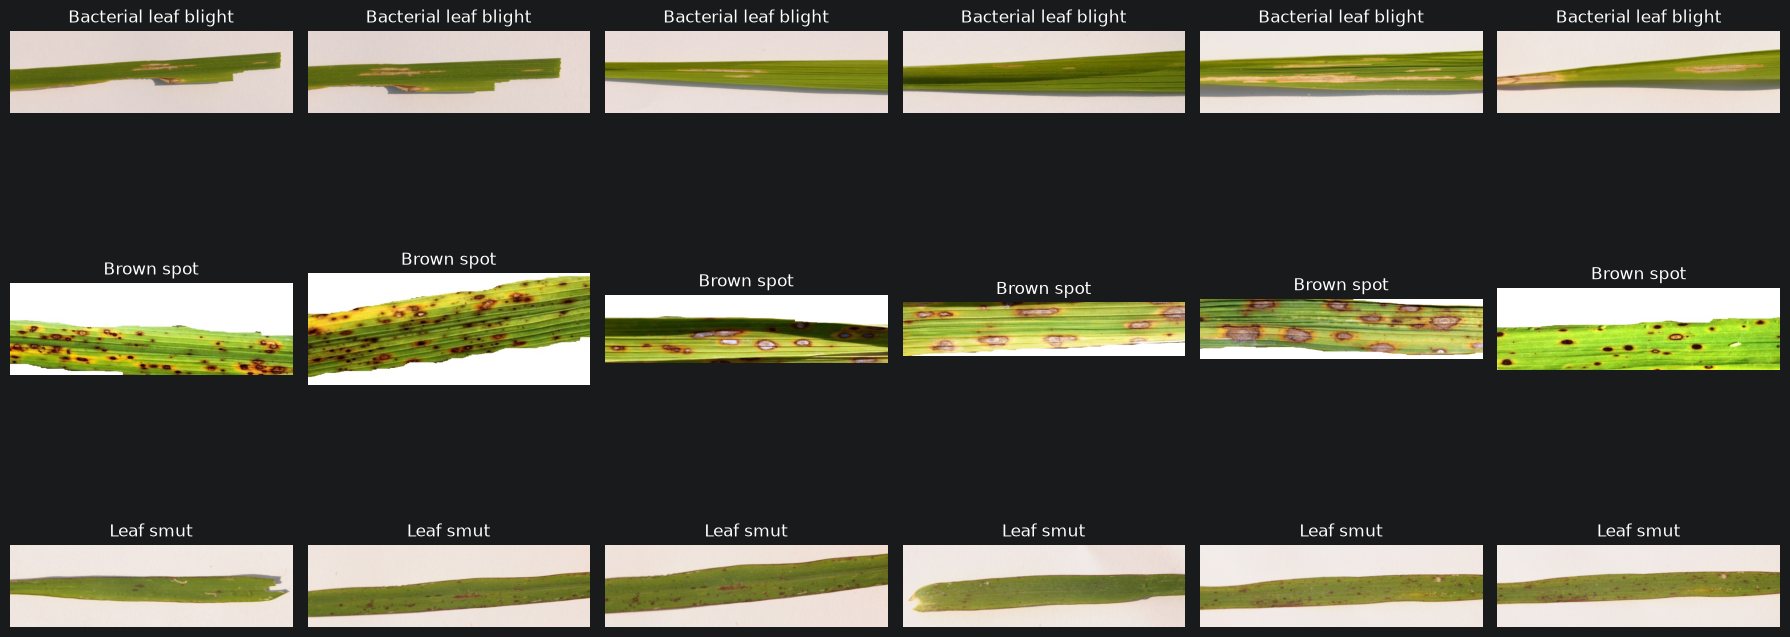

In [22]:
import matplotlib.pyplot as plt
from PIL import Image

images_per_class = 6

fig, axes = plt.subplots(
    3,
    images_per_class,
    figsize=(18,9)
)

for row, class_dir in enumerate(classes):

    image_paths = [
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() == ".jpg"
    ]

    image_paths = image_paths[:images_per_class]

    for col, image_path in enumerate(image_paths):
        with Image.open(image_path) as img:
            axes[row, col].imshow(img)

        axes[row, col].set_title(class_dir.name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [25]:
import numpy as np
from PIL import Image

occupancy_records = []

for class_dir in classes:
    for image_path in class_dir.iterdir():

        if not image_path.is_file() or image_path.suffix.lower() != ".jpg":
            continue

        with Image.open(image_path) as img:
            img_array = np.asarray(img.convert("RGB"))

        # Identify approximately white background pixels
        white_background = np.all(img_array > 220, axis=2)

        # Pixels that are not part of the white background
        leaf_pixels = ~white_background

        occupancy_ratio = leaf_pixels.mean()

        occupancy_records.append({
            "class": class_dir.name,
            "filename": image_path.name,
            "occupancy_ratio": occupancy_ratio
        })

occupancy_df = pd.DataFrame(occupancy_records)

print(occupancy_df.groupby("class")["occupancy_ratio"].agg(
    ["count", "min", "max", "mean", "median"]
).round(3))

                       count    min  max   mean  median
class                                                  
Bacterial leaf blight     40  0.176  1.0  0.717   0.754
Brown spot                40  0.332  1.0  0.702   0.693
Leaf smut                 39  0.226  1.0  0.640   0.628


In [24]:
sample_path = image_paths[0]

with Image.open(sample_path) as img:
    sample_array = np.asarray(img.convert("RGB"))

print("Image:", sample_path)
print("Shape:", sample_array.shape)

print("\nCorner pixels:")
print("Top-left:", sample_array[0, 0])
print("Top-right:", sample_array[0, -1])
print("Bottom-left:", sample_array[-1, 0])
print("Bottom-right:", sample_array[-1, -1])

Image: ..\data\raw\Leaf smut\DSC_0293.JPG
Shape: (897, 3081, 3)

Corner pixels:
Top-left: [241 232 225]
Top-right: [242 232 230]
Bottom-left: [241 230 224]
Bottom-right: [241 230 224]


In [26]:
full_occupancy = occupancy_df[
    occupancy_df["occupancy_ratio"] == 1.0
]

print(full_occupancy[["class", "filename", "occupancy_ratio"]])

print(
    full_occupancy["class"].value_counts()
)

          class      filename  occupancy_ratio
48   Brown spot  DSC_0110.jpg              1.0
49   Brown spot  DSC_0111.jpg              1.0
55   Brown spot  DSC_0117.jpg              1.0
103   Leaf smut  DSC_0500.jpg              1.0
116   Leaf smut  DSC_0514.jpg              1.0
117   Leaf smut  DSC_0515.jpg              1.0
class
Brown spot    3
Leaf smut     3
Name: count, dtype: int64


In [27]:
dark_background_files = occupancy_df[
    occupancy_df["occupancy_ratio"] == 1.0
]

for _, row in dark_background_files.iterrows():
    image_path = DATA_DIR / row["class"] / row["filename"]

    with Image.open(image_path) as img:
        img_array = np.asarray(img.convert("RGB"))

    print(f"\n{row['class']} / {row['filename']}")
    print("Mean RGB:", img_array.mean(axis=(0, 1)).round(2))
    print("Top-left:", img_array[0, 0])
    print("Top-right:", img_array[0, -1])
    print("Bottom-left:", img_array[-1, 0])
    print("Bottom-right:", img_array[-1, -1])


Brown spot / DSC_0110.jpg
Mean RGB: [168.09 158.29  36.1 ]
Top-left: [214 198  17]
Top-right: [220 196  46]
Bottom-left: [134 120  31]
Bottom-right: [240 235 109]

Brown spot / DSC_0111.jpg
Mean RGB: [163.62 154.71  35.26]
Top-left: [172 156   0]
Top-right: [195 187  24]
Bottom-left: [255 243 131]
Bottom-right: [118 116   7]

Brown spot / DSC_0117.jpg
Mean RGB: [149.89 154.15  15.1 ]
Top-left: [200 180  57]
Top-right: [97 99 24]
Bottom-left: [174 120  48]
Bottom-right: [107 121  36]

Leaf smut / DSC_0500.jpg
Mean RGB: [163.91 165.61  67.16]
Top-left: [164 169  69]
Top-right: [158 123  55]
Bottom-left: [102  78  34]
Bottom-right: [75 59 26]

Leaf smut / DSC_0514.jpg
Mean RGB: [ 73.39 105.56  48.89]
Top-left: [ 5 10  6]
Top-right: [ 9 11  6]
Bottom-left: [12 12 10]
Bottom-right: [ 5 10  6]

Leaf smut / DSC_0515.jpg
Mean RGB: [ 86.3  121.73  55.81]
Top-left: [4 9 3]
Top-right: [ 8 10  5]
Bottom-left: [ 6 11  7]
Bottom-right: [ 9 11  6]


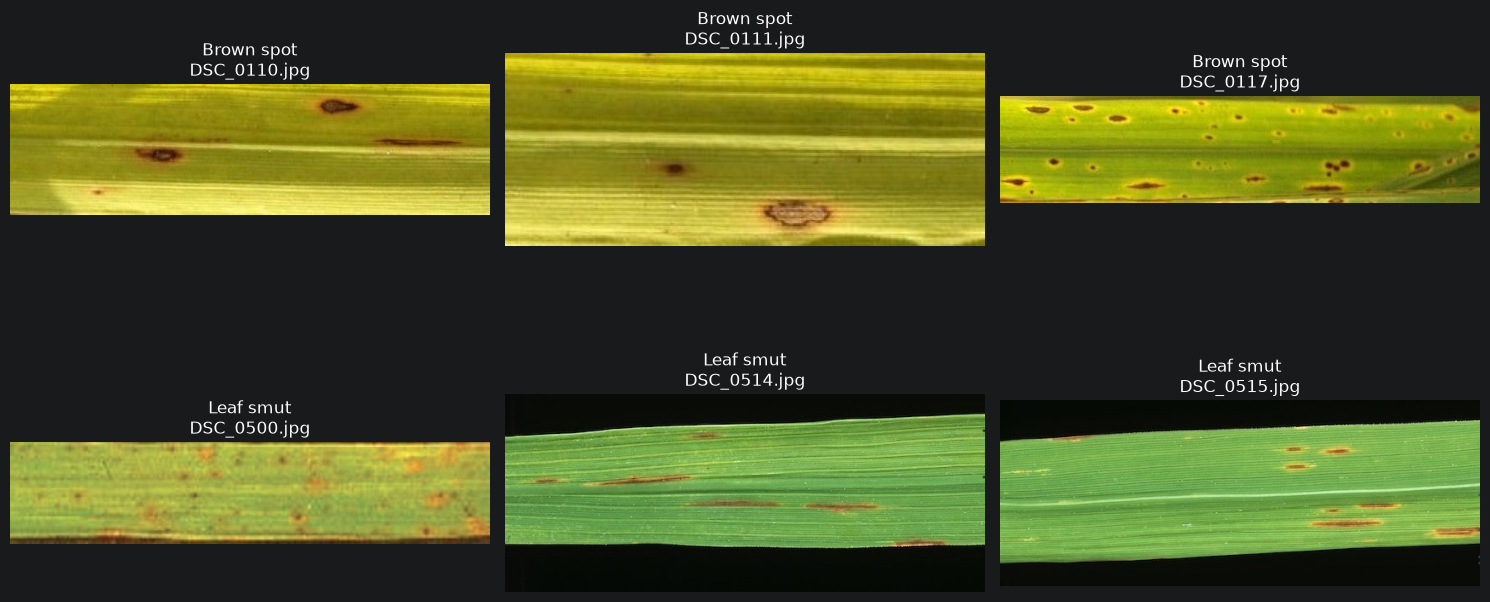

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (_, row) in zip(axes.flat, dark_background_files.iterrows()):
    image_path = DATA_DIR / row["class"] / row["filename"]

    with Image.open(image_path) as img:
        ax.imshow(img)

    ax.set_title(f"{row['class']}\n{row['filename']}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Background Analysis

The dataset contains variation in background appearance.

Most inspected images have light backgrounds, but some images contain
dark or strongly colored backgrounds.

Examples include:
- Brown Spot: DSC_0110.jpg, DSC_0111.jpg, DSC_0117.jpg
- Leaf Smut: DSC_0500.jpg, DSC_0514.jpg, DSC_0515.jpg

Therefore, background appearance is not completely uniform across the
dataset and should be considered during preprocessing and augmentation.

However, the current observation is based on visual inspection of
representative images and does not establish that background type is
associated with a particular disease class.

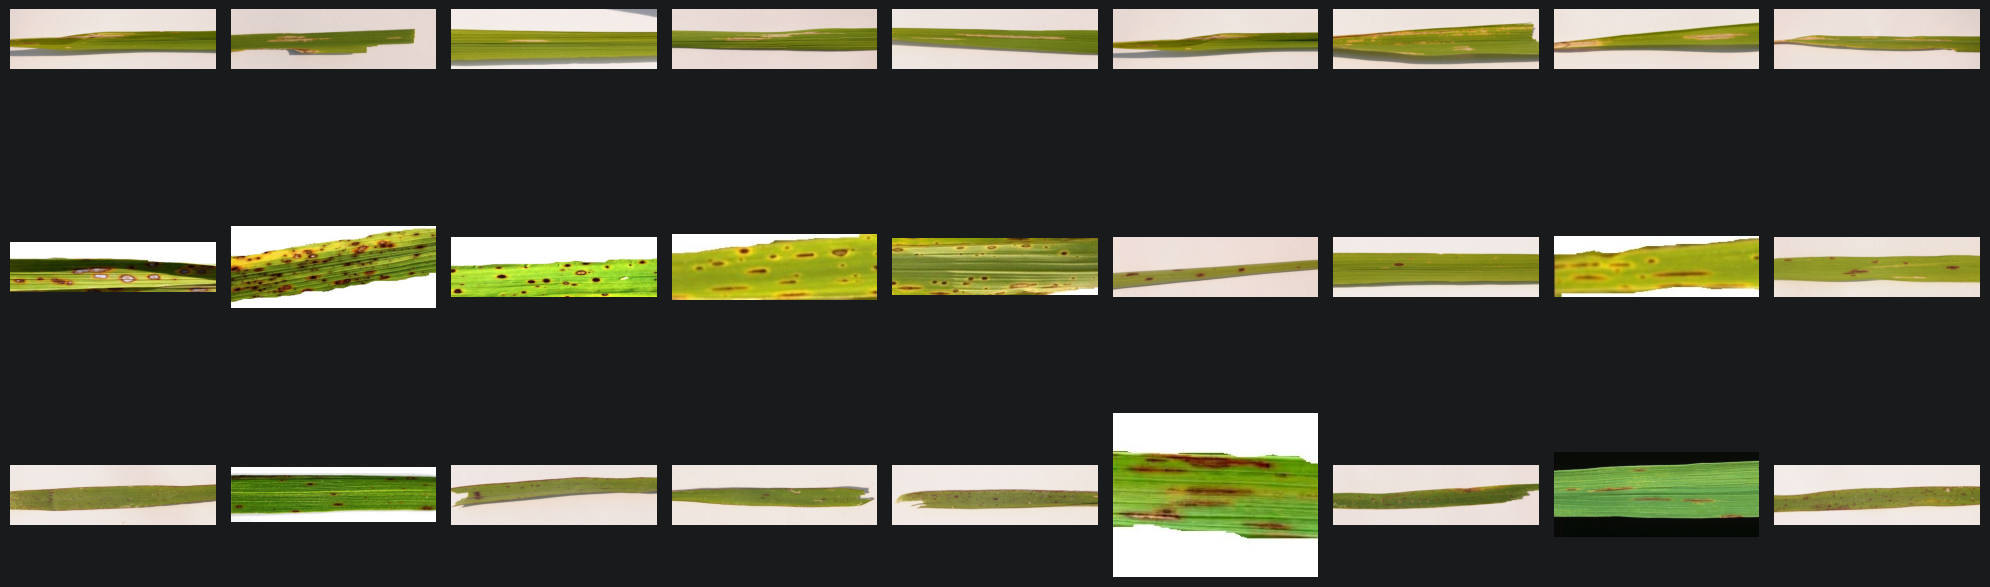

In [29]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

fig, axes = plt.subplots(3, 9, figsize=(20, 8))

for row, class_dir in enumerate(classes):

    image_paths = [
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() == ".jpg"
    ]

    selected_paths = random.sample(
        image_paths,
        min(9, len(image_paths))
    )

    for col, image_path in enumerate(selected_paths):

        with Image.open(image_path) as img:
            axes[row, col].imshow(img)

        axes[row, col].axis("off")

    axes[row, 0].set_ylabel(
        class_dir.name,
        fontsize=12
    )

plt.tight_layout()
plt.show()

## Within-Class Visual Variation

### Bacterial Leaf Blight
- Leaf size varies across images.
- Leaves are generally horizontal and positioned near the center.
- Framing varies, with some images showing more background and others
  showing a closer view of the leaf.
- Background is mostly light/white, with some variation.
- Leaves remain clearly visible under the observed lighting conditions.

### Brown Spot
- Leaf size varies across images.
- Leaves are generally horizontal and positioned near the center.
- Some images are more closely framed and contain less background.
- Background is mostly light/white, with some images having colored
  backgrounds.
- Leaves remain clearly visible.
- Visible disease patterns vary across the sampled images.

### Leaf Smut
- Leaf size varies across images.
- Leaves are generally horizontal and positioned near the center.
- Framing varies between images.
- Most images have light backgrounds, while some contain much darker
  backgrounds.
- Leaves remain clearly visible.
- Visible disease patterns vary across the sampled images.

### Overall Observation

There is considerable variation in leaf size, framing, and background
appearance within the dataset. Therefore, the model should be exposed
to this variation during training without allowing these properties to
become unintended class-specific signals.

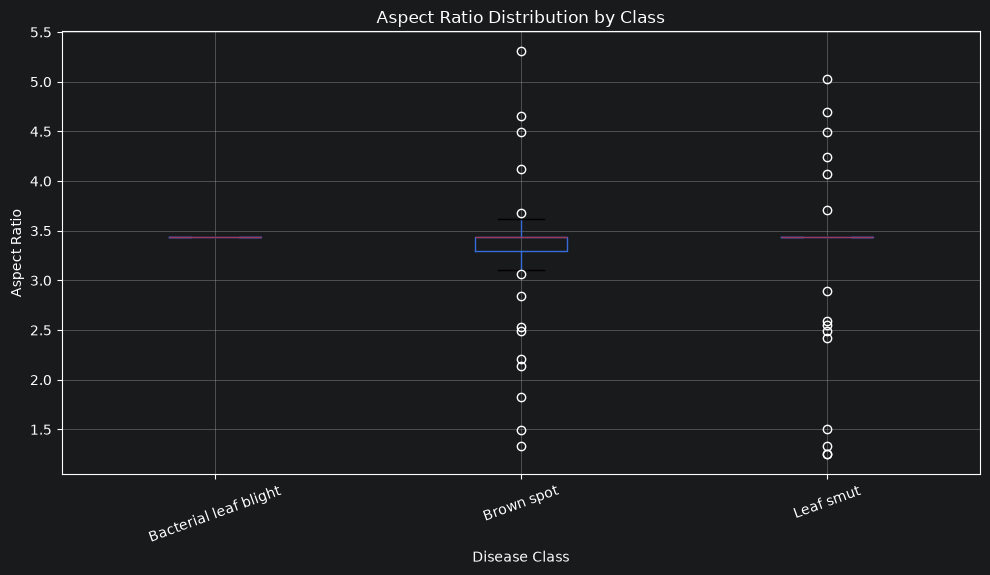

In [30]:
import matplotlib.pyplot as plt

df.boxplot(
    column="aspect_ratio",
    by="class",
    figsize=(10, 6)
)

plt.title("Aspect Ratio Distribution by Class")
plt.suptitle("")
plt.xlabel("Disease Class")
plt.ylabel("Aspect Ratio")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

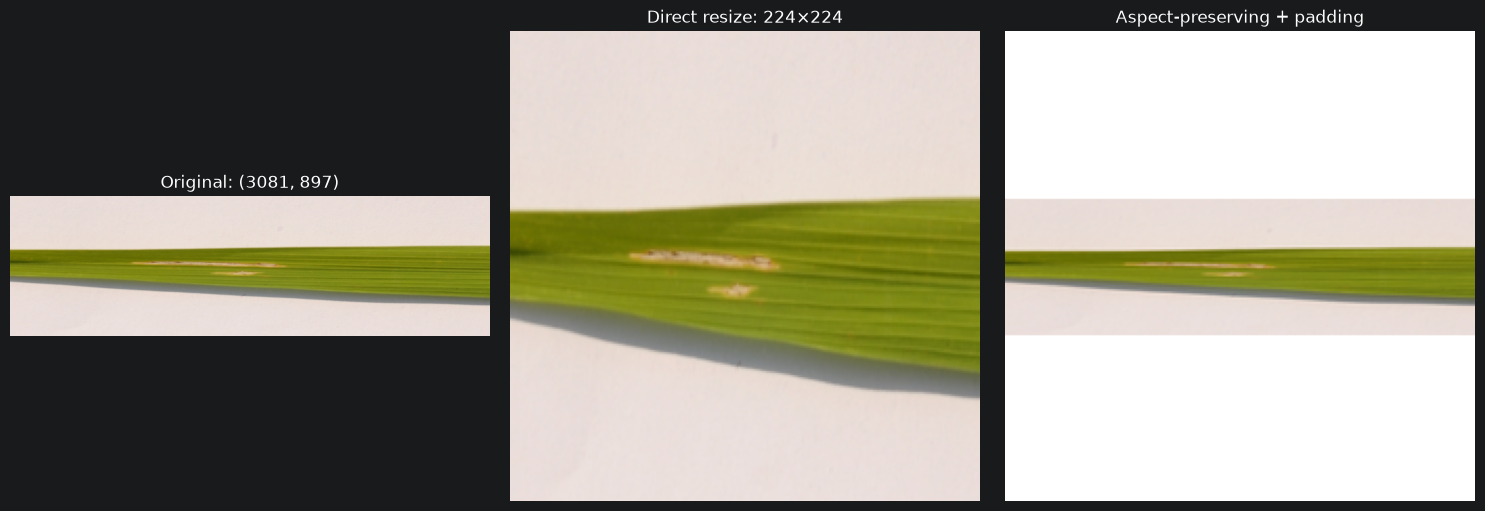

In [31]:
from PIL import ImageOps
import matplotlib.pyplot as plt

# Pick one wide image
sample_path = DATA_DIR / "Bacterial leaf blight" / "DSC_0367.JPG"

with Image.open(sample_path) as img:
    img = img.convert("RGB")

    # Direct resize
    direct_resize = img.resize((224, 224))

    # Aspect-ratio-preserving resize + padding
    resized = ImageOps.contain(img, (224, 224))
    padded = ImageOps.pad(
        img,
        (224, 224),
        method=Image.Resampling.LANCZOS,
        color=(255, 255, 255),
        centering=(0.5, 0.5)
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img)
axes[0].set_title(f"Original: {img.size}")
axes[0].axis("off")

axes[1].imshow(direct_resize)
axes[1].set_title("Direct resize: 224×224")
axes[1].axis("off")

axes[2].imshow(padded)
axes[2].set_title("Aspect-preserving + padding")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [32]:
target_size = 224

df["scale"] = df.apply(
    lambda row: min(
        target_size / row["width"],
        target_size / row["height"]
    ),
    axis=1
)

df["resized_width"] = (df["width"] * df["scale"]).round().astype(int)
df["resized_height"] = (df["height"] * df["scale"]).round().astype(int)

df["padding_pixels"] = (
    target_size * target_size
    - df["resized_width"] * df["resized_height"]
)

df["padding_ratio"] = (
    df["padding_pixels"] / (target_size * target_size)
)

df.groupby("class")["padding_ratio"].agg(
    ["min", "max", "mean", "median"]
).round(3)

,min,max,mean,median
class,,,,
Bacterial leaf blight,0.710,0.710,0.710,0.71
Brown spot,0.250,0.812,0.673,0.71
Leaf smut,0.201,0.799,0.659,0.71


In [34]:
target_sizes = [
    (224, 224),
    (320, 96),
    (448, 128)
]

results = []

for target_width, target_height in target_sizes:

    temp_df = df.copy()

    temp_df["scale"] = temp_df.apply(
        lambda row: min(
            target_width / row["width"],
            target_height / row["height"]
        ),
        axis = 1
    )

    temp_df["resized_width"] = (
        temp_df["width"] * temp_df["scale"]
    ).round().astype(int)

    temp_df["resized_height"] = (
        temp_df["height"] * temp_df["scale"]
    ).round().astype(int)

    temp_df["padding_ratio"] = (
        1
        - (
            temp_df["resized_width"]
            * temp_df["resized_height"]
        )
        / (target_width * target_height)
    )

    summary = (
        temp_df.groupby("class")["padding_ratio"]
        .mean()
        .reset_index()
    )

    summary["target_size"] = (
        f"{target_width}x{target_height}"
    )

    results.append(summary)

padding_comparison = pd.concat(results)

padding_comparison.pivot(
    index="class",
    columns="target_size",
    values="padding_ratio"
).round(3)

target_size,224x224,320x96,448x128
class,,,
Bacterial leaf blight,0.710,0.031,0.018
Brown spot,0.673,0.128,0.123
Leaf smut,0.659,0.145,0.137


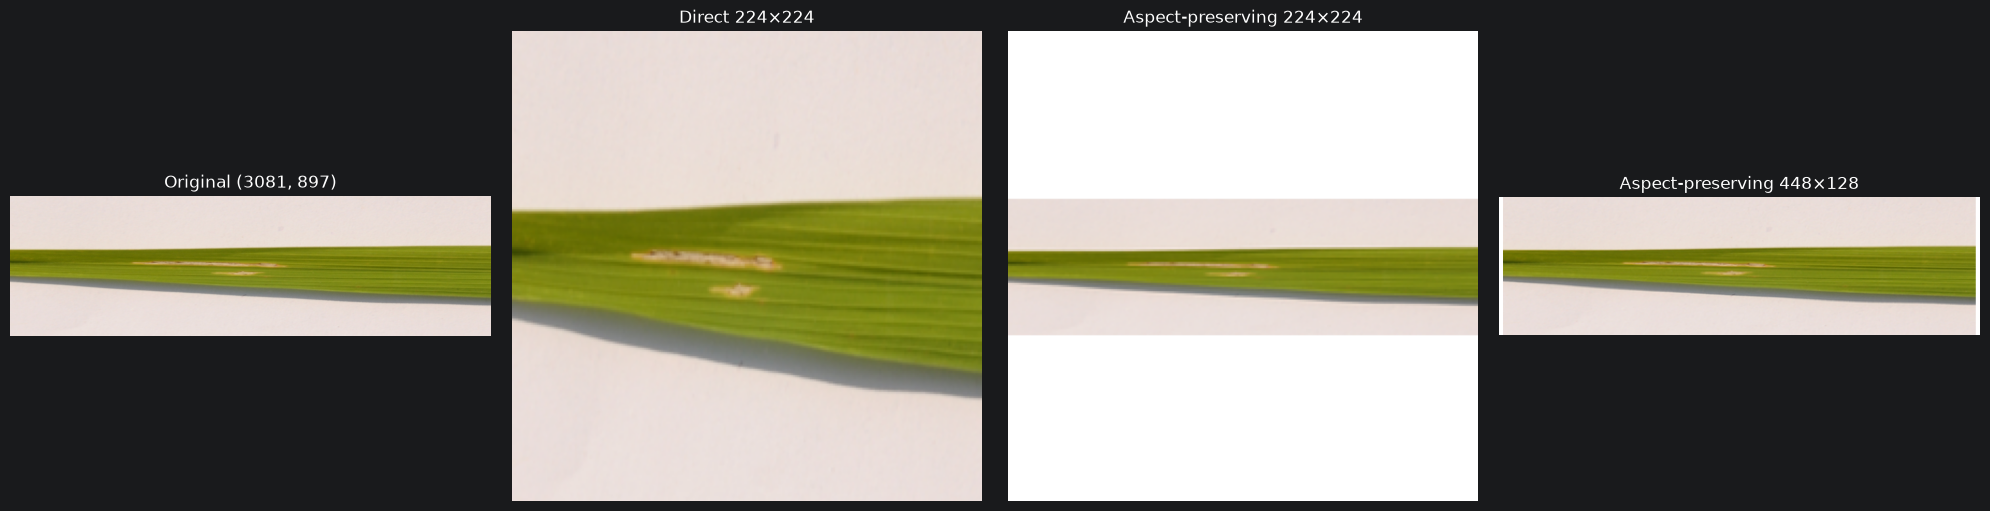

In [35]:
from PIL import ImageOps
import matplotlib.pyplot as plt

sample_path = DATA_DIR / "Bacterial leaf blight" / "DSC_0367.JPG"

with Image.open(sample_path) as img:
    img = img.convert("RGB")

    direct_224 = img.resize((224, 224))

    padded_224 = ImageOps.pad(
        img,
        (224, 224),
        method=Image.Resampling.LANCZOS,
        color=(255, 255, 255),
        centering=(0.5, 0.5)
    )

    padded_448x128 = ImageOps.pad(
        img,
        (448, 128),
        method=Image.Resampling.LANCZOS,
        color=(255, 255, 255),
        centering=(0.5, 0.5)
    )

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img)
axes[0].set_title(f"Original {img.size}")
axes[0].axis("off")

axes[1].imshow(direct_224)
axes[1].set_title("Direct 224×224")
axes[1].axis("off")

axes[2].imshow(padded_224)
axes[2].set_title("Aspect-preserving 224×224")
axes[2].axis("off")

axes[3].imshow(padded_448x128)
axes[3].set_title("Aspect-preserving 448×128")
axes[3].axis("off")

plt.tight_layout()
plt.show()

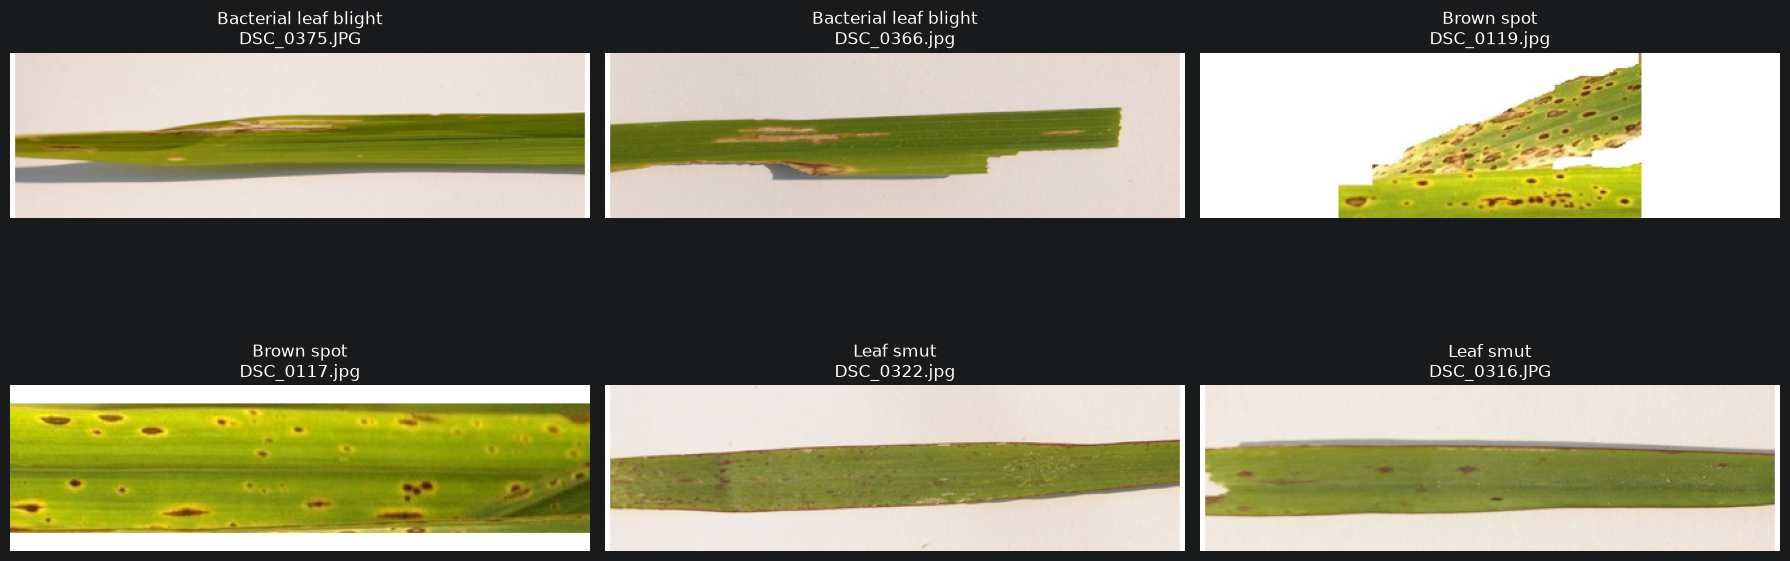

In [37]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import random

random.seed(42)

test_images = []

for class_dir in classes:
    image_paths = [
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg"}
    ]

    # Select 2 images from each class
    selected = random.sample(image_paths, min(2, len(image_paths)))

    for image_path in selected:
        test_images.append(image_path)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for ax, image_path in zip(axes.flat, test_images):

    with Image.open(image_path) as img:
        img = img.convert("RGB")

        processed = ImageOps.pad(
            img,
            (448, 128),
            method=Image.Resampling.LANCZOS,
            color=(255, 255, 255),
            centering=(0.5, 0.5)
        )

        ax.imshow(processed)

    ax.set_title(
        f"{image_path.parent.name}\n{image_path.name}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## 448×128 Visual Check

The images were resized to 448×128 while preserving their aspect
ratio and adding padding where necessary.

Across six representative images from the three disease classes:
- The leaf remains recognizable.
- The leaf shape is preserved.
- Disease patterns remain clearly visible.
- No significant distortion was observed.
- No significant cropping was observed.

Therefore, 448×128 is a promising candidate input resolution for the
next stage of preprocessing experiments.

In [39]:
sample_path = test_images[0]

with Image.open(sample_path) as img:
    img = img.convert("RGB")
    processed = ImageOps.pad(
        img,
        (448, 128),
        method=Image.Resampling.LANCZOS,
        color=(255, 255, 255),
        centering=(0.5, 0.5)
    )

image_array = np.asarray(processed, dtype=np.float32)

print("Shape:", image_array.shape)
print("Before normalization:")
print("Min:", image_array.min())
print("Max:", image_array.max())

normalized_array = image_array / 255.0

print("\nAfter normalization:")
print("Min:", normalized_array.min())
print("Max:", normalized_array.max())

Shape: (128, 448, 3)
Before normalization:
Min: 0.0
Max: 255.0

After normalization:
Min: 0.0
Max: 1.0


## Normalization Check

The processed image has shape:

128 × 448 × 3

Before normalization, pixel values range from 0 to 255.

After dividing pixel values by 255.0, the values range from 0 to 1.

Normalization changes pixel values but does not change the image dimensions
or number of color channels.

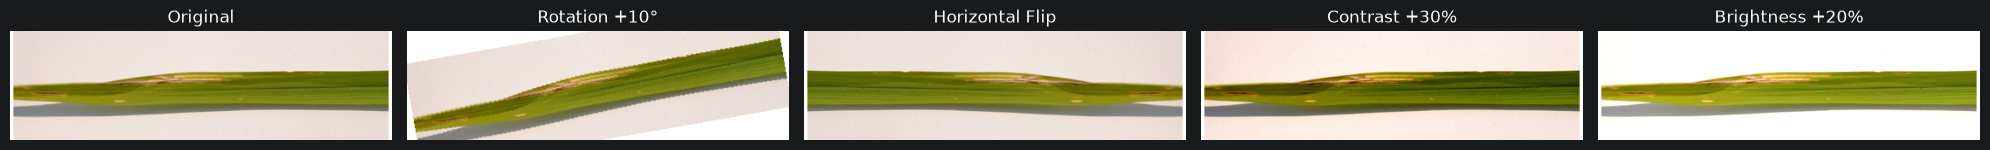

In [40]:
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt

sample_path = test_images[0]

with Image.open(sample_path) as img:
    img = img.convert("RGB")

    # Resize while preserving aspect ratio
    base = ImageOps.pad(
        img,
        (448, 128),
        method=Image.Resampling.LANCZOS,
        color=(255, 255, 255),
        centering=(0.5, 0.5)
    )

    # 1. Small rotation
    rotated = base.rotate(10, expand=False, fillcolor=(255, 255, 255))

    # 2. Horizontal flip
    flipped = ImageOps.mirror(base)

    # 3. Small contrast change
    contrast = ImageEnhance.Contrast(base).enhance(1.3)

    # 4. Small brightness change
    brightness = ImageEnhance.Brightness(base).enhance(1.2)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

images = [
    (base, "Original"),
    (rotated, "Rotation +10°"),
    (flipped, "Horizontal Flip"),
    (contrast, "Contrast +30%"),
    (brightness, "Brightness +20%")
]

for ax, (image, title) in zip(axes, images):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Augmentation Visual Check

The following transformations were tested on representative images:

- Small rotation (+10°)
- Horizontal flip
- Contrast adjustment
- Brightness adjustment

All tested transformations produced visually realistic rice-leaf images,
and the visible disease patterns remained identifiable.

These transformations are therefore candidates for the training-time
augmentation pipeline. Their final ranges will be validated during model
experimentation.

In [46]:
dataset_records = []

for class_dir in classes:
    for image_path in class_dir.iterdir():

        if not image_path.is_file():
            continue

        if image_path.suffix.lower() not in {".jpg", ".jpeg"}:
            continue

        dataset_records.append({
            "image_path": str(image_path),
            "class": class_dir.name
        })

dataset_df = pd.DataFrame(dataset_records)

print("Total images:", len(dataset_df))
print("\nClass distribution:")
print(dataset_df["class"].value_counts())

Total images: 119

Class distribution:
class
Bacterial leaf blight    40
Brown spot               40
Leaf smut                39
Name: count, dtype: int64


In [47]:
print(dataset_df["class"].value_counts())

class
Bacterial leaf blight    40
Brown spot               40
Leaf smut                39
Name: count, dtype: int64


In [48]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    dataset_df,
    test_size=0.30,
    stratify=dataset_df["class"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

In [49]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 83
Validation: 18
Test: 18


In [50]:
print("\nTrain distribution:")
print(train_df["class"].value_counts())

print("\nValidation distribution:")
print(val_df["class"].value_counts())

print("\nTest distribution:")
print(test_df["class"].value_counts())


Train distribution:
class
Brown spot               28
Bacterial leaf blight    28
Leaf smut                27
Name: count, dtype: int64

Validation distribution:
class
Leaf smut                6
Brown spot               6
Bacterial leaf blight    6
Name: count, dtype: int64

Test distribution:
class
Leaf smut                6
Brown spot               6
Bacterial leaf blight    6
Name: count, dtype: int64


In [51]:
print("\nTest distribution:")
print(test_df["class"].value_counts())


Test distribution:
class
Leaf smut                6
Brown spot               6
Bacterial leaf blight    6
Name: count, dtype: int64


In [52]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

split_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

split_df = split_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(split_df.head())
print("\nTotal:", len(split_df))

                            image_path       class       split
0  ..\data\raw\Brown spot\DSC_0306.JPG  Brown spot       train
1  ..\data\raw\Brown spot\DSC_0302.JPG  Brown spot  validation
2  ..\data\raw\Brown spot\DSC_0109.jpg  Brown spot       train
3   ..\data\raw\Leaf smut\DSC_0506.jpg   Leaf smut       train
4  ..\data\raw\Brown spot\DSC_0121.jpg  Brown spot       train

Total: 119


In [53]:
print(
    pd.crosstab(
        split_df["split"],
        split_df["class"]
    )
)

class       Bacterial leaf blight  Brown spot  Leaf smut
split                                                   
test                            6           6          6
train                          28          28         27
validation                      6           6          6


In [54]:
split_df.to_csv(
    "../data/split_manifest.csv",
    index=False
)

print("Split manifest saved.")

Split manifest saved.
